In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph,START,END

load_dotenv()

True

In [2]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [3]:
class sentimentSchema(BaseModel):
    sentiment : Literal['positive','negative'] = Field(description="Sentiment of the review")

structured_model = model.with_structured_output(sentimentSchema)

In [ ]:
prompt = 'What is the sentiment of the following review - The software is good'
response = structured_model.invoke(prompt)
sentiment = response.get("sentiment") if isinstance(response, dict) else getattr(response, "sentiment", None)
sentiment

'positive'

In [5]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive','negative']
    diagnosis: dict
    response: str

In [6]:
def find_sentiment(state: ReviewState):
    prompt = f"for the following review find out the sentiment \n {state['review']}"
    response = structured_model.invoke(prompt)
    sentiment = response.get("sentiment") if isinstance(response, dict) else getattr(response, "sentiment", None)
    return {'sentiment':sentiment}

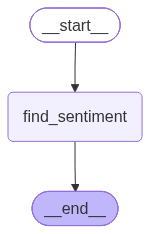

In [7]:
graph = StateGraph(ReviewState)
graph.add_node('find_sentiment',find_sentiment)
graph.add_edge(START,'find_sentiment')
graph.add_edge('find_sentiment',END)

workflow = graph.compile()
workflow